In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# This is just to ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\Mall Customers.csv")

data.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [8]:
# Understanding dataset structure

print(data.shape)   # number of rows and columns
print("\n-------------------------------------------------------")
print(data.columns) # column names
print("\n-------------------------------------------------------")
print(data.info())  # data types and null values

(200, 7)

-------------------------------------------------------
Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (k$)', 'Spending Score (1-100)'],
      dtype='object')

-------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB
None


In [9]:
# Selecting important columns for clustering


X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Display selected data
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [10]:
# Scaling is important because KMeans uses distance
# If we don't scale, one feature may dominate

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Checking scaled values
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [11]:
# Creating KMeans model
# Here we assume 5 clusters 

kmeans = KMeans(n_clusters=5, random_state=42)

# Fitting model and predicting clusters
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Checking updated dataset
data.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,M,19,High School,Married,15,39,4
1,2,M,21,Graduate,Single,15,81,2
2,3,F,20,Graduate,Married,16,6,4
3,4,F,23,High School,Unknown,16,77,2
4,5,F,31,Uneducated,Married,17,40,4


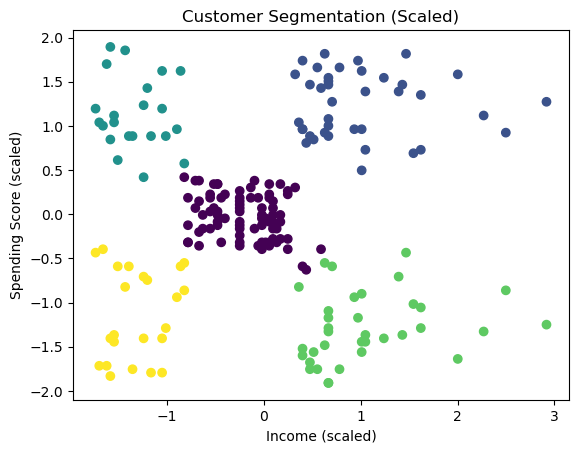

In [12]:
# Plotting clusters to see grouping

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=data['Cluster'])

plt.title("Customer Segmentation (Scaled)")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.show()

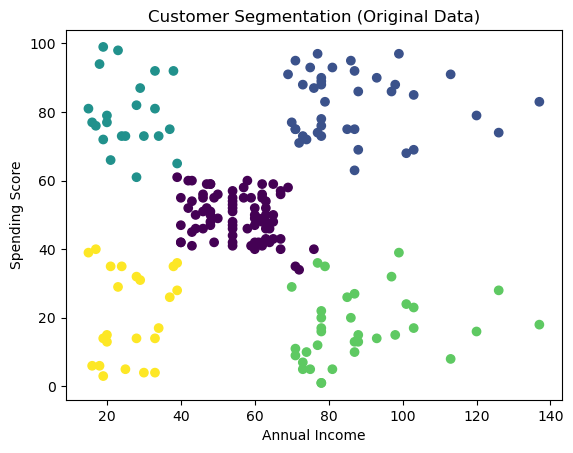

In [13]:
# Plotting clusters in original scale (more understandable)

plt.scatter(data['Annual Income (k$)'], 
            data['Spending Score (1-100)'], 
            c=data['Cluster'])

plt.title("Customer Segmentation (Original Data)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [14]:
# Creating a target column for prediction
# Here we define: Spending Score > 50 means customer will buy

data['Target'] = (data['Spending Score (1-100)'] > 50).astype(int)

# Checking dataset
data.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster,Target
0,1,M,19,High School,Married,15,39,4,0
1,2,M,21,Graduate,Single,15,81,2,1
2,3,F,20,Graduate,Married,16,6,4,0
3,4,F,23,High School,Unknown,16,77,2,1
4,5,F,31,Uneducated,Married,17,40,4,0


In [15]:
# Selecting features for prediction
# Including cluster because it improves model performance

X = data[['Age', 'Annual Income (k$)', 'Cluster']]
y = data['Target']

# Splitting into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (160, 3)
Testing data size: (40, 3)


In [16]:
# Creating Random Forest model

model = RandomForestClassifier()

# Training the model
model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
# Predicting on test data

y_pred = model.predict(X_test)

# Checking few predictions
print(y_pred[:10])

[0 1 1 0 1 1 0 0 0 0]


In [18]:
# Calculating accuracy

acc = accuracy_score(y_test, y_pred)
print("Accuracy of Random Forest:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy of Random Forest: 0.875
Confusion Matrix:
 [[23  3]
 [ 2 12]]


In [19]:
# Trying another algorithm for comparison

from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()
model2.fit(X_train, y_train)

# Prediction
y_pred2 = model2.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.675
